# STARIT Tutorial: Interpreting STARIT Image Intensities

This tutorial explains what the pixel intensities of a STARIT image do, and do not, tell you. A common first instinct is to read a brighter image as "more expression." In STARIT this is not the case. Two cells with the **same** number of transcripts of a gene can produce images with very different mean and total (sum) intensities, and the difference is driven by **how spread out** the transcripts are. Spread-out expression produces higher mean and sum intensities, while punctate (tightly clustered) expression produces lower ones. More information on STARIT can be found in the [paper](https://doi.org/10.64898/2025.12.18.695193).

This tutorial assumes you have worked through [Running STARIT on Simulated Dataset](simulated_data_example.ipynb). It reuses that notebook's simulated nuclear–perinuclear dataset and STARIT settings. [Choosing the Pixel Size (`dx`) and Blur (`blur`) Parameters](dx_blur_parameters_tutorial.ipynb) is a useful companion for the role of `blur`.

### Learning Objectives

By the end of the notebook, you will be able to:

1. measure mean, sum, and maximum intensity from saved STARIT images
2. explain why spread-out expression gives higher mean and sum intensities than punctate expression with the same transcript count
3. relate image intensity to the raw transcript density through per-image min–max normalization
4. recognize that STARIT image intensity does not encode transcript abundance and
5. check these effects on nuclear versus perinuclear cells in the simulated dataset

### Input Files

- Two toy cells defined directly in this notebook (no input file).
- `data/simulated_nuclear_peri/simulation_nuclear_peri_dataset.csv`: one transcript per row, with `x_position`, `y_position`, `gene_id`, `cell_id`, and `group_id`.

Toy-cell images are written to `data/simulation_intensity/`. Run the notebook from the repository root so these relative paths resolve correctly. The workflow is: environment setup → toy example → intensity measurement → why it happens → spread continuum → intensity versus counts → simulated dataset.

## 1. Reproducible Environment and Installation

This notebook uses the same environment as the other STARIT tutorials. See **Section 1** of [Running STARIT on Simulated Dataset](simulated_data_example.ipynb) for the full software and version table and the Conda setup. This notebook needs only STARIT, NumPy, Matplotlib, pandas, Pillow, and SciPy. It does not use PyTorch or ResNet-101.

If you are running this notebook in **Google Colab** or a standalone **Jupyter Notebook**, uncomment and execute the cell below to clone the repository, install the pinned package versions, and set up STARIT in editable mode.

> **Note for Google Colab Users:** Once the dependencies install, you may need to restart the runtime (**Runtime > Restart session**) for updated package versions to take effect.

In [1]:
# 1. Clone the repository (skip if running locally from within the cloned repository)
#!git clone https://github.com/JEFworks-Lab/STARIT.git
#%cd STARIT

# 2. Install required dependencies with exact pinned versions
#!python -m pip install \
#  numpy==1.26.4 \
#  matplotlib==3.8.0 \
#  pandas==2.1.4 \
#  pillow==10.2.0 \
#  scipy==1.11.4

# 3. Install the local STARIT package
#!python -m pip install -e .

## 2. Import Packages and Define Helper Functions

We import the required packages and define four helpers used throughout the notebook:

- `rasterize()` runs `starit()` and returns the rasterized array shown in the returned figure (values in [0, 1]).
- `rasterize_to_png()` runs `starit()` and writes the figure with `save_image()`, exactly as the other tutorials do. Passing an in-memory buffer instead of a file path gives the same PNG without writing it to disk.
- `intensity_metrics()` loads a saved STARIT PNG and reports its intensity statistics.
- `raw_density()` reproduces the summed Gaussian kernels that `starit()` builds internally **before** normalization. `starit()` does not return this array, so we recompute it here to look inside the image (Section 5 checks that it matches `starit()` exactly).

In [2]:
# Standard-library utilities
import contextlib
import io
import os

# Data handling and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.stats import spearmanr

# STARIT rasterization
from starit import get_bounding_box, save_image, starit

# Fix the random seed so the simulated spread continuum is repeatable.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Colors for spread versus punctate expression (matches the other tutorials).
SPREAD_COLOR = "#eb6834"
PUNCTATE_COLOR = "#2a78d6"
GROUP_COLORS = {"group2": PUNCTATE_COLOR, "group3": SPREAD_COLOR}

output_dir = "data/simulation_intensity"
os.makedirs(output_dir, exist_ok=True)


def rasterize(bbox, x, y, dx, blur):
    # Run STARIT and return the min-max normalized raster array from the returned figure.
    with contextlib.redirect_stdout(io.StringIO()):
        _, _, fig = starit(bbox, np.asarray(x), np.asarray(y), dx=dx, blur=blur, draw=10000)
    raster = fig.axes[0].images[0].get_array()[..., 0].copy()  # single blur -> grayscale
    plt.close(fig)
    return raster


def rasterize_to_png(bbox, x, y, dx, blur, save_path):
    # Run STARIT and write the image with save_image(); save_path may be a file path or a buffer.
    with contextlib.redirect_stdout(io.StringIO()):
        _, _, fig = starit(bbox, np.asarray(x), np.asarray(y), dx=dx, blur=blur, draw=10000)
    save_image(fig, save_path)
    plt.close(fig)


def intensity_metrics(image_source):
    # Summarize the grayscale intensities (0-255) of one saved STARIT image.
    # STARIT PNGs are RGBA with identical R, G, B channels and a constant alpha of 255,
    # so we convert to a single grayscale channel. Averaging all four RGBA channels
    # would add a constant 255 alpha channel and inflate the mean.
    pixels = np.asarray(Image.open(image_source).convert("L"), dtype=float)
    return {
        "mean intensity": pixels.mean(),
        "sum intensity": pixels.sum(),
        "max intensity": pixels.max(),
        "fraction of pixels > 0": (pixels > 0).mean(),
    }


def raw_density(bbox, x, y, dx, blur):
    # Sum of per-transcript Gaussian kernels, computed as in starit() but NOT normalized.
    # Each kernel is normalized to sum to 1, so the whole array sums to the transcript count.
    min_x, max_x, min_y, max_y = bbox
    X_ = np.arange(min_x, max_x, dx)
    Y_ = np.arange(min_y, max_y, dx)
    XX, YY = np.meshgrid(X_, Y_)
    W = np.zeros(XX.shape)
    r = int(np.ceil(blur * 4))  # window half-width in pixels
    sigma = 2.0 * blur * dx     # Gaussian standard deviation in coordinate units

    for x_, y_ in zip(x, y):
        col = int(np.round((x_ - X_[0]) / dx))
        row = int(np.round((y_ - Y_[0]) / dx))
        row0, row1 = np.clip([row - r, row + r], 0, W.shape[0] - 1)
        col0, col1 = np.clip([col - r, col + r], 0, W.shape[1] - 1)
        k = np.exp(-((XX[row0:row1 + 1, col0:col1 + 1] - x_) ** 2 +
                     (YY[row0:row1 + 1, col0:col1 + 1] - y_) ** 2) / (2.0 * sigma ** 2))
        W[row0:row1 + 1, col0:col1 + 1] += k / k.sum()
    return W

## 3. A Toy Example: Same Counts, Different Spread

We build two cells by hand, each with **10 transcripts of the same gene**:

- **Cell 1 (spread):** transcripts are distributed along the full length of the cell (*y* from 0 to 200).
- **Cell 2 (punctate):** transcripts are packed into one small cluster near the middle of the cell (*y* from 90 to 110).

A gene-count matrix would record the same value, 10, for both cells.

In [3]:
# Two cells with 10 transcripts each of one gene.
cell1_data = pd.DataFrame({
    "x_position": [10, 0, 20, 10, 10, 0, 0, 0, 20, 20],
    "y_position": [0, 50, 100, 150, 200, 0, 50, 100, 150, 200],
})

cell2_data = pd.DataFrame({
    "x_position": [10, 0, 10, 20, 0, 0, 20, 10, 20, 10],
    "y_position": [95, 105, 90, 100, 110, 95, 105, 90, 100, 110],
})

toy_cells = {"Cell 1 (spread)": cell1_data, "Cell 2 (punctate)": cell2_data}
toy_colors = {"Cell 1 (spread)": SPREAD_COLOR, "Cell 2 (punctate)": PUNCTATE_COLOR}

for name, data in toy_cells.items():
    print(f"{name}: {len(data)} transcripts")

Cell 1 (spread): 10 transcripts
Cell 2 (punctate): 10 transcripts


### Get a Shared Bounding Box

As in the other tutorials, both cells must share one bounding box so that their images have the same coordinate frame, grid, and size. We compute it from the transcripts of both cells together. `expand=2` doubles the frame around the transcripts so that the Gaussian kernels near the edges are not cut off.

In [4]:
# Calculate one coordinate frame for both toy cells.
all_x = pd.concat([cell1_data["x_position"], cell2_data["x_position"]])
all_y = pd.concat([cell1_data["y_position"], cell2_data["y_position"]])
toy_bbox = get_bounding_box(all_x, all_y, expand=2)
print("Bounding box [min_x, max_x, min_y, max_y]:")
print(toy_bbox)

Bounding box [min_x, max_x, min_y, max_y]:
(-10.0, 30.0, -100.0, 300.0)


### Rasterize and Save the Toy Cells

We rasterize each cell with `dx = 3` and `blur = 3` and save the images to `data/simulation_intensity/`. With these settings, each transcript becomes a Gaussian with a standard deviation of 2 · `blur` · `dx` = 18 coordinate units (see the [`dx` and `blur` tutorial](dx_blur_parameters_tutorial.ipynb)), large enough that the kernels of the punctate cluster overlap heavily.

In [5]:
# Rasterize both toy cells and write their STARIT images.
toy_dx, toy_blur = 3.0, 3.0
toy_paths = {}

for name, data in toy_cells.items():
    file_name = "cell1_spread.png" if "spread" in name else "cell2_punctate.png"
    save_path = os.path.join(output_dir, file_name)
    rasterize_to_png(toy_bbox, data["x_position"], data["y_position"], toy_dx, toy_blur, save_path)
    toy_paths[name] = save_path
    print(f"STARIT result saved for {name}: {save_path}")

STARIT result saved for Cell 1 (spread): data/simulation_intensity/cell1_spread.png
STARIT result saved for Cell 2 (punctate): data/simulation_intensity/cell2_punctate.png


### Visualize the Transcripts and STARIT Images

For each cell, the left panel shows the transcript coordinates and the right panel shows the saved STARIT image, read back from disk. Both images span the same bounding box.

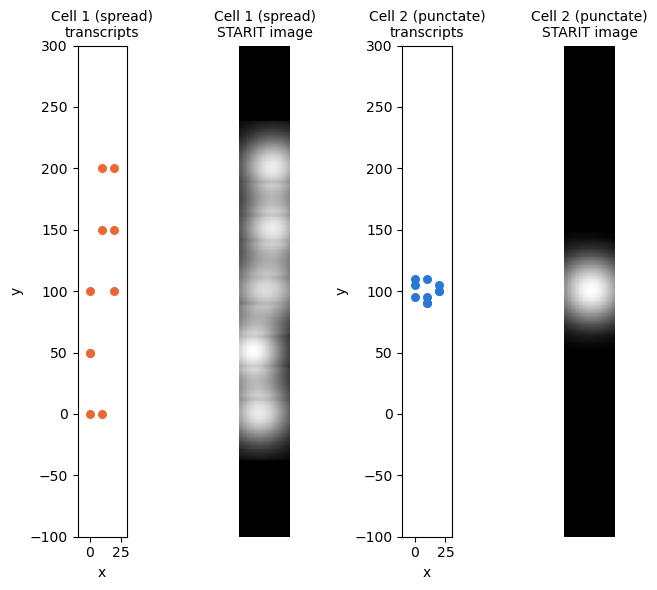

In [6]:
# Plot transcript coordinates next to the saved STARIT images.
fig, axes = plt.subplots(1, 4, figsize=(7, 6))

for i, (name, data) in enumerate(toy_cells.items()):
    ax_points, ax_image = axes[2 * i], axes[2 * i + 1]

    ax_points.scatter(data["x_position"], data["y_position"], s=30, color=toy_colors[name])
    ax_points.set_xlim(toy_bbox[0], toy_bbox[1])
    ax_points.set_ylim(toy_bbox[2], toy_bbox[3])
    ax_points.set_aspect("equal")
    ax_points.set_title(f"{name}\ntranscripts", fontsize=10)
    ax_points.set_xlabel("x")
    ax_points.set_ylabel("y")

    ax_image.imshow(Image.open(toy_paths[name]).convert("L"), cmap="gray", vmin=0, vmax=255)
    ax_image.set_title(f"{name}\nSTARIT image", fontsize=10)
    ax_image.axis("off")

plt.tight_layout()
plt.show()

The spread cell lights up a long stripe of the image. The punctate cell produces one bright spot, and the rest of its image is black.

## 4. Measure Image Intensity

We now load each saved PNG and compute four intensity statistics on its grayscale values (0–255):

- **Mean intensity:** average pixel value over the whole image.
- **Sum intensity:** total of all pixel values (mean × number of pixels). Both images have the same size, so mean and sum rank the cells identically.
- **Max intensity:** brightest pixel.
- **Fraction of pixels > 0:** how much of the image is lit at all.

In [7]:
# Compute intensity statistics from the saved STARIT images.
toy_metrics = pd.DataFrame({name: intensity_metrics(path) for name, path in toy_paths.items()}).T
toy_metrics.insert(0, "transcripts", [len(data) for data in toy_cells.values()])

ratio = toy_metrics["sum intensity"].iloc[0] / toy_metrics["sum intensity"].iloc[1]
print(toy_metrics.round(3))
print(f"\nSpread / punctate sum-intensity ratio: {ratio:.2f}")

                   transcripts  mean intensity  sum intensity  max intensity  \
Cell 1 (spread)             10         103.570      1452259.0          254.0   
Cell 2 (punctate)           10          25.179       353063.0          254.0   

                   fraction of pixels > 0  
Cell 1 (spread)                     0.694  
Cell 2 (punctate)                   0.244  

Spread / punctate sum-intensity ratio: 4.11


##### Interpretation

Both cells have **10 transcripts**, yet the spread cell's mean and sum intensities are roughly four times higher than the punctate cell's. The maximum intensity is the same for both (close to 255; the PNG is resampled when saved, so the brightest pixel can land at 254). More of the spread cell's image is lit, and its lit pixels are brighter on average.

**Spread-out expression produces higher mean and sum intensities than punctate expression with the same transcript count.** The next section explains why.

## 5. Why Spread Expression Is Brighter: Per-Image Min–Max Normalization

`starit()` builds each image in two steps (see Section 3 of the [`dx` and `blur` tutorial](dx_blur_parameters_tutorial.ipynb) for details):

1. **Raw density.** Each transcript is replaced by a Gaussian kernel that is normalized to sum to 1. The kernels are added together. The raw density of a cell therefore always sums to its transcript count, no matter where the transcripts are.
2. **Min–max normalization.** The figure that `starit()` returns, and that `save_image()` writes, rescales the raw density so its smallest pixel is 0 and its **largest pixel is 1** (255 in the PNG). This rescaling is done independently for every image.

Step 2 is what links intensity to spread. In a punctate cell, the kernels pile up on top of each other and produce one very tall peak. Dividing by that tall peak makes everything else in the image dim. In a spread cell, the kernels barely overlap, the peak is low, and dividing by a low peak keeps most of the signal bright.

### Check That `raw_density()` Matches `starit()`

First, we confirm that min–max normalizing our `raw_density()` reproduces the image that `starit()` draws.

In [8]:
# Compare our raw density, after min-max normalization, with the STARIT raster.
toy_raw = {}
for name, data in toy_cells.items():
    W = raw_density(toy_bbox, data["x_position"].values, data["y_position"].values, toy_dx, toy_blur)
    W_normalized = (W - W.min()) / (W.max() - W.min())
    starit_raster = rasterize(toy_bbox, data["x_position"], data["y_position"], toy_dx, toy_blur)
    toy_raw[name] = W
    print(f"{name}: raw density matches starit() after normalization -> {np.allclose(W_normalized, starit_raster)}")

Cell 1 (spread): raw density matches starit() after normalization -> True
Cell 2 (punctate): raw density matches starit() after normalization -> True


### Compare Raw and Normalized Intensities

We now compare the two cells before and after normalization.

In [9]:
# Summarize raw density and normalized raster for both toy cells.
rows = []
for name, data in toy_cells.items():
    W = toy_raw[name]
    raster = rasterize(toy_bbox, data["x_position"], data["y_position"], toy_dx, toy_blur)
    rows.append({
        "cell": name,
        "transcripts": len(data),
        "raw sum": W.sum(),
        "raw peak": W.max(),
        "normalized sum": raster.sum(),
        "transcripts / raw peak": len(data) / W.max(),
    })
print(pd.DataFrame(rows).set_index("cell").round(4))

                   transcripts  raw sum  raw peak  normalized sum  \
cell                                                                
Cell 1 (spread)             10     10.0    0.0132        756.8997   
Cell 2 (punctate)           10     10.0    0.0542        184.4420   

                   transcripts / raw peak  
cell                                       
Cell 1 (spread)                  756.8997  
Cell 2 (punctate)                184.4420  


The table shows three things:

- **Raw sum** is 10 for both cells. Before normalization, the two images contain exactly the same total signal, matching their equal transcript counts.
- **Raw peak** is about four times higher for the punctate cell, because its kernels overlap.
- **Normalized sum** equals **transcripts / raw peak** (the background pixels are 0, so normalization simply divides by the peak).

This gives a simple rule for interpreting STARIT intensity:

$$\text{sum intensity} \;\propto\; \frac{\text{number of transcripts}}{\text{peak raw density}}, \qquad \text{mean intensity} = \frac{\text{sum intensity}}{\text{number of pixels}}.$$

For a fixed number of transcripts, **anything that lowers the peak density, such as spreading transcripts apart, raises the mean and sum intensity.**

### Profile Along the Cell

A line profile through the middle of each cell (taking the maximum across the short *x* axis at each *y*) shows the same effect visually. On the left, both raw profiles enclose the same area, but the punctate profile is tall and narrow. On the right, after each profile is divided by its own peak, the spread profile stays high along the whole cell and the punctate profile is high only near *y* = 100.

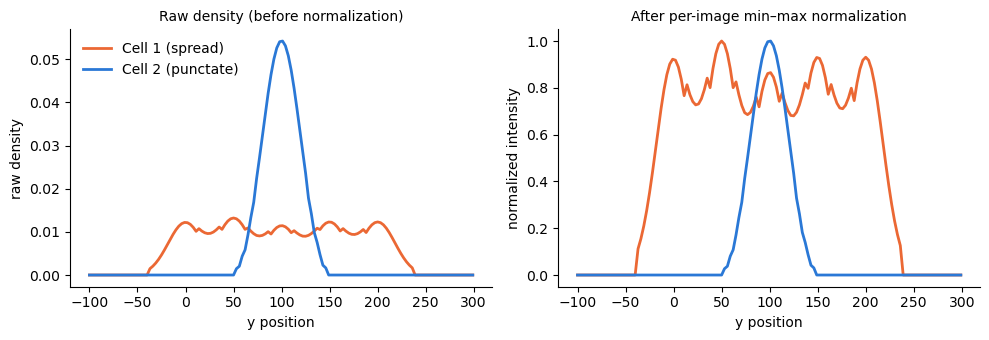

In [10]:
# Plot raw and normalized density along the long axis of each toy cell.
y_grid = np.arange(toy_bbox[2], toy_bbox[3], toy_dx)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for name, W in toy_raw.items():
    profile = W.max(axis=1)
    axes[0].plot(y_grid, profile, color=toy_colors[name], lw=2, label=name)
    axes[1].plot(y_grid, profile / W.max(), color=toy_colors[name], lw=2, label=name)

axes[0].set_title("Raw density (before normalization)", fontsize=10)
axes[0].set_ylabel("raw density")
axes[1].set_title("After per-image min–max normalization", fontsize=10)
axes[1].set_ylabel("normalized intensity")
for ax in axes:
    ax.set_xlabel("y position")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## 6. A Continuum From Punctate to Spread

The toy example compares two extremes. To see the relationship more generally, we draw 20 transcript positions uniformly inside a disk once and then scale the disk radius from 2 to 50 coordinate units. Every image has the **same 20 transcripts in the same relative arrangement**; only the spread changes. We use `dx = 1` and `blur = 2` (σ = 4 units) in a fixed 120 × 120 frame.

All transcripts stay inside the frame. This matters: `starit()` clips each kernel window to the image boundary, so transcripts outside the bounding box get piled onto the edge pixels and create artificial bright spots. Always compute the bounding box from all of your transcripts, as the other tutorials do.

In [11]:
# Scale one fixed set of 20 transcripts from punctate to spread.
rng = np.random.default_rng(RANDOM_SEED)
n_transcripts = 20
angles = rng.uniform(0, 2 * np.pi, n_transcripts)
radii = np.sqrt(rng.uniform(0, 1, n_transcripts))  # uniform density inside the unit disk

continuum_bbox = (-60.0, 60.0, -60.0, 60.0)
continuum_dx, continuum_blur = 1.0, 2.0
spread_radii = [2, 5, 10, 20, 30, 40, 50]

continuum_rows = []
continuum_rasters = {}
for spread_radius in spread_radii:
    x = spread_radius * radii * np.cos(angles)
    y = spread_radius * radii * np.sin(angles)

    buffer = io.BytesIO()
    rasterize_to_png(continuum_bbox, x, y, continuum_dx, continuum_blur, buffer)
    buffer.seek(0)
    metrics = intensity_metrics(buffer)

    W = raw_density(continuum_bbox, x, y, continuum_dx, continuum_blur)
    continuum_rasters[spread_radius] = rasterize(continuum_bbox, x, y, continuum_dx, continuum_blur)
    continuum_rows.append({"spread radius": spread_radius, "transcripts": n_transcripts,
                           "raw peak": W.max(), **metrics})

continuum_metrics = pd.DataFrame(continuum_rows).set_index("spread radius")
print(continuum_metrics.round(4))

               transcripts  raw peak  mean intensity  sum intensity  \
spread radius                                                         
2                       20    0.2004          1.7459       237724.0   
5                       20    0.1516          2.3188       315724.0   
10                      20    0.0737          4.8069       654512.0   
20                      20    0.0307         11.5196      1568517.0   
30                      20    0.0249         14.2177      1935896.0   
40                      20    0.0213         16.5266      2250279.0   
50                      20    0.0187         18.8806      2570796.0   

               max intensity  fraction of pixels > 0  
spread radius                                         
2                      255.0                  0.0273  
5                      255.0                  0.0384  
10                     255.0                  0.0675  
20                     255.0                  0.1412  
30                     255.0  

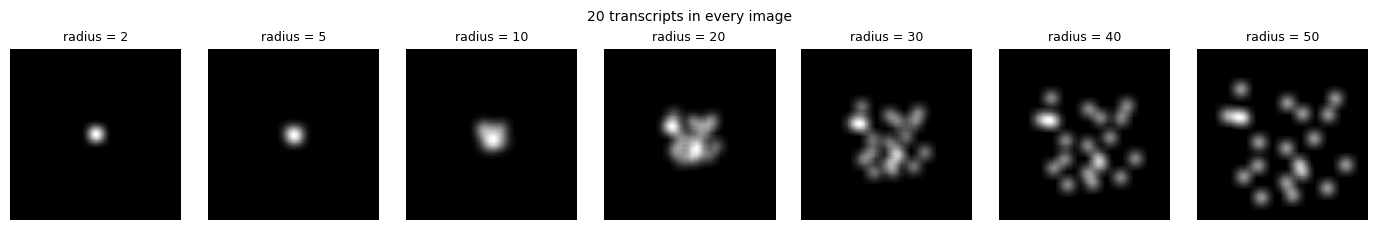

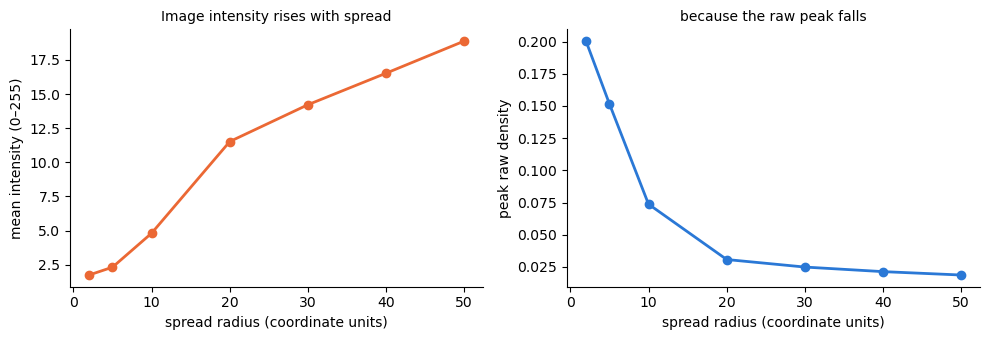

In [12]:
# Show the continuum images and plot intensity against spread.
fig, axes = plt.subplots(1, len(spread_radii), figsize=(2 * len(spread_radii), 2.3))
for ax, spread_radius in zip(axes, spread_radii):
    ax.imshow(continuum_rasters[spread_radius], cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"radius = {spread_radius}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"{n_transcripts} transcripts in every image", fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(continuum_metrics.index, continuum_metrics["mean intensity"], "o-", color=SPREAD_COLOR, lw=2)
axes[0].set_ylabel("mean intensity (0–255)")
axes[0].set_title("Image intensity rises with spread", fontsize=10)
axes[1].plot(continuum_metrics.index, continuum_metrics["raw peak"], "o-", color=PUNCTATE_COLOR, lw=2)
axes[1].set_ylabel("peak raw density")
axes[1].set_title("because the raw peak falls", fontsize=10)
for ax in axes:
    ax.set_xlabel("spread radius (coordinate units)")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

##### Interpretation

With the same 20 transcripts, mean intensity increases steadily as the transcripts spread out, while the peak raw density falls. At a radius of 2, all 20 kernels sit on top of each other: the image is one bright dot and the mean intensity is very low. As the radius grows, the kernels separate, the peak drops, and more of the image is lit after normalization.

The steepest change happens while the kernels go from heavily overlapping to mostly separate (radius 5 to 20 here, for σ = 4 units). After that, the gain per unit of spread slows down: the peak is set by the one or two transcripts that still happen to sit close together, and further spreading mainly lights up more of the background. How far this range extends depends on `blur`: a larger blur makes kernels overlap over longer distances, so intensity keeps changing over a wider range of spreads.

## 7. Image Intensity Does Not Encode Transcript Counts

Because every image is normalized by its own peak, multiplying the number of transcripts while keeping their arrangement fixed does not change the image at all. To show this, we rasterize the spread toy cell twice: once with its 10 transcripts and once with every transcript repeated five times (50 transcripts).

In [13]:
# Repeat every transcript 5 times: counts go from 10 to 50 but the pattern is unchanged.
x_10, y_10 = cell1_data["x_position"].values, cell1_data["y_position"].values
x_50, y_50 = np.repeat(x_10, 5), np.repeat(y_10, 5)

raster_10 = rasterize(toy_bbox, x_10, y_10, toy_dx, toy_blur)
raster_50 = rasterize(toy_bbox, x_50, y_50, toy_dx, toy_blur)

print(f"10 transcripts: mean normalized intensity = {raster_10.mean():.4f}")
print(f"50 transcripts: mean normalized intensity = {raster_50.mean():.4f}")
print(f"Images identical: {np.allclose(raster_10, raster_50)}")

10 transcripts: mean normalized intensity = 0.4035
50 transcripts: mean normalized intensity = 0.4035
Images identical: True


##### Interpretation

Five times more transcripts produce an **identical** image. STARIT image intensity reflects the **relative spatial distribution** of a gene's transcripts within a cell, not how many there are. Conversely, a cell with fewer transcripts can have a brighter image than a cell with more transcripts if its transcripts are more spread out.

This is why the main tutorials offer **expression-weighted** features: multiplying each gene's ResNet-101 embedding by its scaled count adds back the abundance information that per-image normalization removes. See Section 7 of [Running STARIT on Simulated Dataset](simulated_data_example.ipynb).

## 8. Nuclear Versus Perinuclear Cells in the Simulated Dataset

Finally, we check that the same effect appears in the simulated dataset. Groups 2 and 3 are the ideal comparison: both express **`gene2` at 50 transcripts per cell**, and they differ only in localization. Group 2 is **nuclear** (transcripts packed in a disk near the cell center) and group 3 is **perinuclear** (transcripts in a wider ring around the nucleus). The perinuclear ring covers a larger area, so its transcripts are more spread out.

We use the same settings as [Running STARIT on Simulated Dataset](simulated_data_example.ipynb): one bounding box computed from all transcripts, `dx = 1`, and `blur = 1`. Each image is written with `save_image()` to an in-memory buffer, which produces the same PNG as writing to disk, and then measured with `intensity_metrics()`.

### Load the Data

In [14]:
# Load the noise-free simulation and calculate its shared bounding box.
dataset = pd.read_csv("data/simulated_nuclear_peri/simulation_nuclear_peri_dataset.csv")
bounding_box = get_bounding_box(dataset["x_position"], dataset["y_position"])

gene2_data = dataset[(dataset["gene_id"] == "gene2") & (dataset["group_id"].isin(["group2", "group3"]))]
print(gene2_data.groupby("group_id").agg(cells=("cell_id", "nunique"), transcripts=("cell_id", "size")))
print("\nBounding box [min_x, max_x, min_y, max_y]:")
print(bounding_box)

          cells  transcripts
group_id                    
group2       20         1000
group3       20         1000

Bounding box [min_x, max_x, min_y, max_y]:
(30.599999999999994, 193.4, 31.599999999999994, 194.4)


### Measure Intensity and Spread for Every Cell

For each cell we record its STARIT intensity statistics, its peak raw density, and a simple measure of spread: the **radius of gyration**, the root-mean-square distance of the transcripts from their centroid. A larger radius of gyration means more spread-out transcripts.

In [15]:
# Rasterize gene2 for every group2 and group3 cell and record intensity and spread.
dataset_dx, dataset_blur = 1.0, 1.0
cell_rows = []
example_rasters = {}

for (group_id, cell_id), cell in gene2_data.groupby(["group_id", "cell_id"]):
    x, y = cell["x_position"].values, cell["y_position"].values

    buffer = io.BytesIO()
    rasterize_to_png(bounding_box, x, y, dataset_dx, dataset_blur, buffer)
    buffer.seek(0)

    W = raw_density(bounding_box, x, y, dataset_dx, dataset_blur)
    radius_of_gyration = np.sqrt(np.mean((x - x.mean()) ** 2 + (y - y.mean()) ** 2))
    cell_rows.append({"group_id": group_id, "cell_id": cell_id, "transcripts": len(x),
                      "radius of gyration": radius_of_gyration, "raw peak": W.max(),
                      **intensity_metrics(buffer)})

    if group_id not in example_rasters:
        example_rasters[group_id] = (cell_id, rasterize(bounding_box, x, y, dataset_dx, dataset_blur))

cell_metrics = pd.DataFrame(cell_rows)
summary_columns = ["transcripts", "radius of gyration", "raw peak", "mean intensity", "sum intensity"]
print(cell_metrics.groupby("group_id")[summary_columns].mean().round(3))

          transcripts  radius of gyration  raw peak  mean intensity  \
group_id                                                              
group2           50.0              20.710     0.120           4.067   
group3           50.0              35.177     0.105           4.612   

          sum intensity  
group_id                 
group2        553743.40  
group3        627958.85  


### Visualize Example Cells and Group Distributions

The top row shows one example `gene2` image per group. The bottom panels compare the mean and sum intensity of all 20 cells in each group; each point is one cell and the black bar marks the group median.

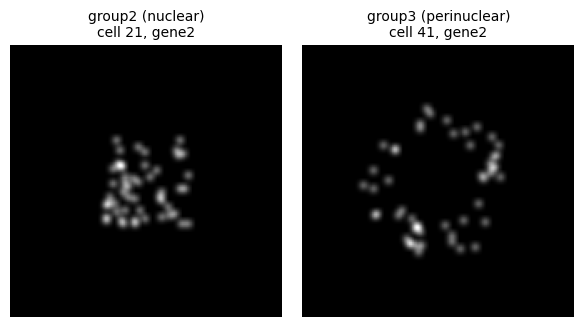

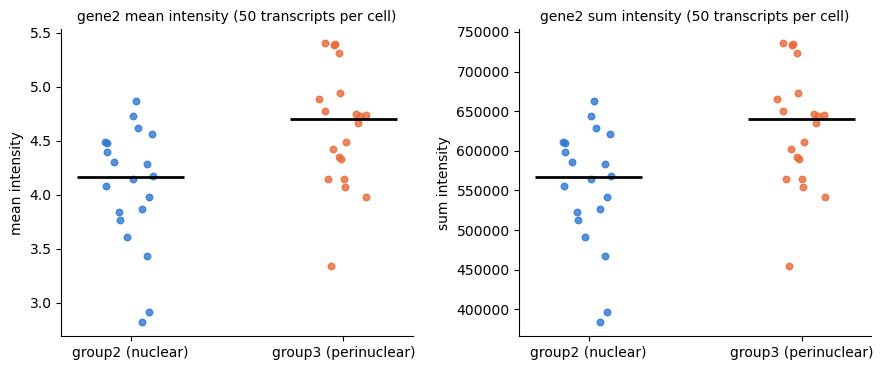

In [16]:
# Example images for each group.
labels = {"group2": "group2 (nuclear)", "group3": "group3 (perinuclear)"}

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, (group_id, (cell_id, raster)) in zip(axes, example_rasters.items()):
    ax.imshow(raster, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"{labels[group_id]}\ncell {cell_id}, gene2", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Per-cell mean and sum intensity by group.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, metric in zip(axes, ["mean intensity", "sum intensity"]):
    for position, group_id in enumerate(["group2", "group3"]):
        values = cell_metrics.loc[cell_metrics["group_id"] == group_id, metric]
        jitter = np.random.default_rng(position).uniform(-0.12, 0.12, len(values))
        ax.scatter(position + jitter, values, s=22, color=GROUP_COLORS[group_id], alpha=0.8)
        ax.hlines(values.median(), position - 0.25, position + 0.25, color="black", lw=2)
    ax.set_xticks([0, 1], [labels["group2"], labels["group3"]])
    ax.set_ylabel(metric)
    ax.set_title(f"gene2 {metric} (50 transcripts per cell)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Relate Intensity to Spread

To see whether intensity tracks spread at the level of individual cells, we plot each cell's mean intensity against its radius of gyration and against 1 / peak raw density, and report Spearman rank correlations.

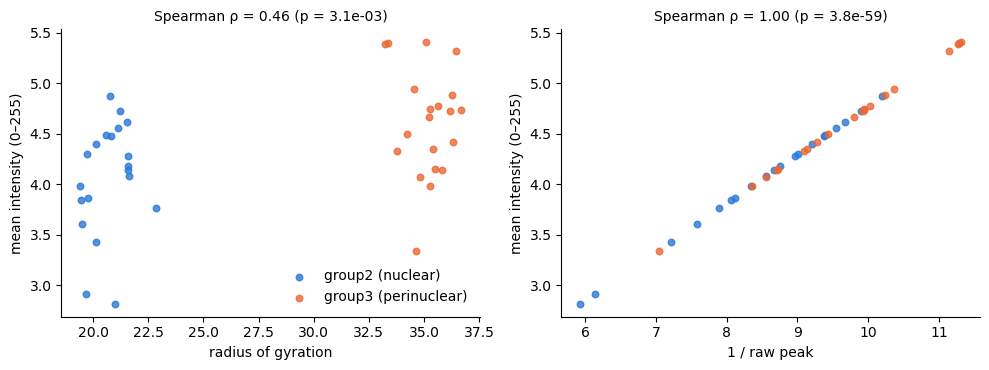

In [17]:
# Correlate per-cell mean intensity with spread and with 1 / peak raw density.
cell_metrics["1 / raw peak"] = 1.0 / cell_metrics["raw peak"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, predictor in zip(axes, ["radius of gyration", "1 / raw peak"]):
    for group_id in ["group2", "group3"]:
        subset = cell_metrics[cell_metrics["group_id"] == group_id]
        ax.scatter(subset[predictor], subset["mean intensity"], s=22,
                   color=GROUP_COLORS[group_id], alpha=0.8, label=labels[group_id])
    rho, p_value = spearmanr(cell_metrics[predictor], cell_metrics["mean intensity"])
    ax.set_title(f"Spearman ρ = {rho:.2f} (p = {p_value:.1e})", fontsize=10)
    ax.set_xlabel(predictor)
    ax.set_ylabel("mean intensity (0–255)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

##### Interpretation

With the same gene and the same 50 transcripts per cell, the more spread-out **perinuclear** cells (group 3) have a larger radius of gyration, a lower peak raw density, and **higher mean and sum intensities on average** than the **nuclear** cells (group 2), as in the toy example.

The two groups overlap, however. Intensity is set by the **densest spot** in each image, not by the overall size of the pattern. A nuclear cell whose transcripts happen to be evenly spaced can be brighter than a perinuclear cell with a few transcripts landing close together. This is why the radius of gyration is only moderately correlated with intensity, while 1 / peak raw density predicts it almost perfectly, as the formula in Section 5 says it should.

## 9. Summary: How to Read STARIT Intensity

- **STARIT intensity is relative within each image.** Every image is min–max normalized independently, so its brightest pixel is always 255. Summed intensity is proportional to the number of transcripts divided by the image's peak raw density.
- **Spread-out expression gives higher mean and sum intensities; punctate expression gives lower ones,** even with identical transcript counts. Overlapping kernels in a punctate pattern create a tall peak that dims the rest of the image after normalization.
- **Intensity does not measure expression level.** The same pattern with five times more transcripts gives the same image. Use gene counts, or the expression-weighted features from the main tutorials, when abundance matters.
- **The effect depends on `blur` and `dx`.** Kernel overlap, and therefore the size of the effect, grows with the physical blur σ = 2 · `blur` · `dx`. Only compare intensities between images rasterized with the same bounding box, `dx`, and `blur`.
- **Keep all transcripts inside the bounding box.** Transcripts outside the frame are clipped onto the edge pixels and create artificial bright spots.
- **For a CNN such as ResNet-101, these intensity differences are part of the signal.** They are one way that subcellular spatial organization, which gene counts cannot capture, reaches the extracted image features.